# Image Augmentation
:label:`sec_image_augmentation`

In :numref:`sec_alexnet`, 
we mentioned that large datasets 
are a prerequisite
for the success of
deep neural networks
in various applications.
*Image augmentation* 
generates similar but distinct training examples
after a series of random changes to the training images, thereby expanding the size of the training set.
Alternatively,
image augmentation can be motivated
by the fact that 
random tweaks of training examples 
allow models to rely less on
certain attributes, thereby improving their generalization ability.
For example, we can crop an image in different ways to make the object of interest appear in different positions, thereby reducing the dependence of a model on the position of the object. 
We can also adjust factors such as brightness and color to reduce a model's sensitivity to color.
It is probably true
that image augmentation was indispensable
for the success of AlexNet at that time.
In this section we will discuss this widely used technique in computer vision.

In [4]:
using Pkg;
Pkg.activate("../../d2lai")
using DataAugmentation, Images
using d2lai, Flux, MLDatasets
using Flux, MPI, NCCL, CUDA
using Random
using Flux.Optimisers
using Flux.Zygote
using Statistics
using MLDatasets
using Plots

  Activating project at `~/d2l-julia/d2lai`


## Common Image Augmentation Methods

In our investigation of common image augmentation methods, we will use the following $400\times 500$ image an example.


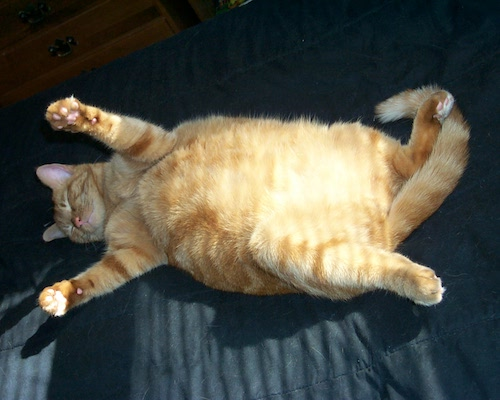

In [5]:
img = load("../img/cat1.jpg")

Most image augmentation methods have a certain degree of randomness. To make it easier for us to observe the effect of image augmentation, next we define an auxiliary function `apply`. This function runs the image augmentation method `aug` multiple times on the input image `img` and shows all the results.


In [6]:
function apply_(img, aug; nrows = 2, ncols = 4, scale = 1.5)
    item = Image(img)
    Y = map(1:(nrows*ncols)) do _ 
        apply(aug, item) |> itemdata
    end
    mosaicview(Y...; nrow = nrows)
end

apply_ (generic function with 1 method)

### Flipping and Cropping

Flipping the image left and right usually does not change the category of the object. 
This is one of the earliest and most widely used methods of image augmentation.
Next, we use the `transforms` module to create the `RandomFlipLeftRight` instance, which flips
an image left and right with a 50% chance.

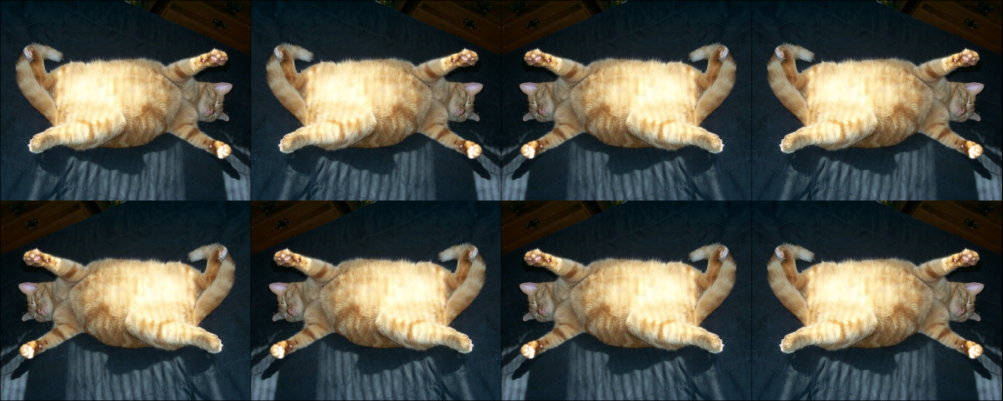

In [7]:
aug = DataAugmentation.compose(Maybe(FlipX{2}()))
apply_(img, aug)  

Flipping up and down is not as common as flipping left and right. But at least for this example image, flipping up and down does not hinder recognition.
Next, we create a `RandomFlipTopBottom` instance to flip
an image up and down with a 50% chance.

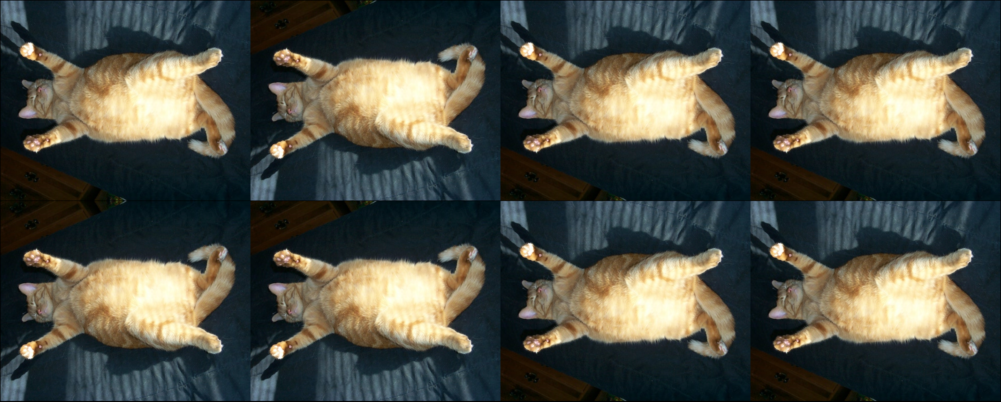

In [8]:
aug = Maybe(FlipY{2}())
apply_(img, aug)

In the example image we used, the cat is in the middle of the image, but this may not be the case in general. 
In :numref:`sec_pooling`, we explained that the pooling layer can reduce the sensitivity of a convolutional layer to the target position.
In addition, we can also randomly crop the image to make objects appear in different positions in the image at different scales, which can also reduce the sensitivity of a model to the target position.

In the code below, we [**randomly crop**] an area with an area of $10\% \sim 100\%$ of the original area each time, and the ratio of width to height of this area is randomly selected from $0.5 \sim 2$. Then, the width and height of the region are both scaled to 200 pixels. 
Unless otherwise specified, the random number between $a$ and $b$ in this section refers to a continuous value obtained by random and uniform sampling from the interval $[a, b]$.



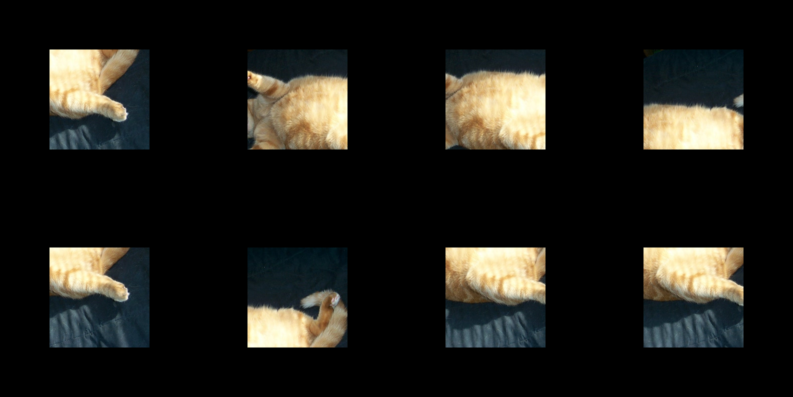

In [9]:
aug = RandomCrop((200,200))
apply_(img, aug)

### Changing Colors

Another augmentation method is changing colors. We can change four aspects of the image color: brightness, contrast, saturation, and hue. In the example below, we randomly change the brightness of the image to a value between 50% ($1-0.5$) and 150% ($1+0.5$) of the original image.


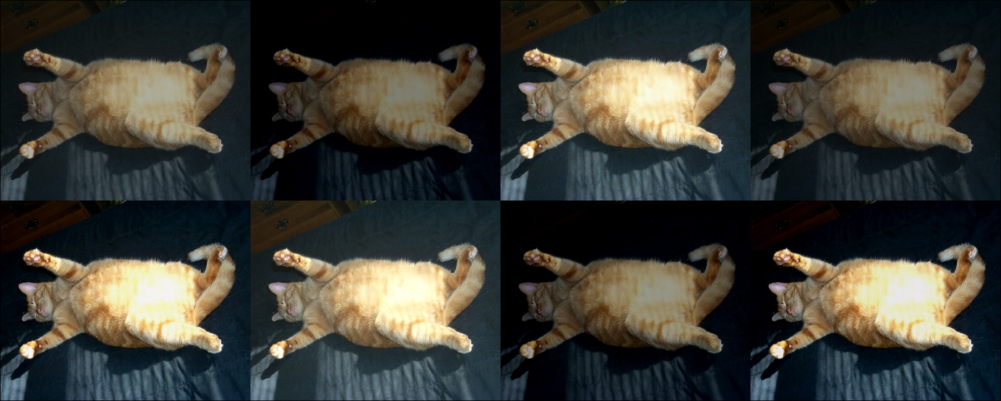

In [10]:
aug = DataAugmentation.compose(AdjustBrightness(0.5), AdjustContrast(0.5))
apply_(img, aug)

## Training with Image Augmentation

Let's train a model with image augmentation.
Here we use the CIFAR-10 dataset instead of the Fashion-MNIST dataset that we used before. 
This is because the position and size of the objects in the Fashion-MNIST dataset have been normalized, while the color and size of the objects in the CIFAR-10 dataset have more significant differences. 
The first 32 training images in the CIFAR-10 dataset are shown below.

In order to obtain definitive results during prediction, we usually only apply image augmentation to training examples, and do not use image augmentation with random operations during prediction. 
Here we only use the simplest random left-right flipping method. In addition, we use a `ToTensor` instance to convert a minibatch of images into the format required by the deep learning framework, i.e., 
32-bit floating point numbers between 0 and 1 with the shape of (batch size, number of channels, height, width).



In [11]:

struct CIFAR10Data{T,V,L,A} <: d2lai.AbstractData 
    train::T
    val::V
    labels::L
    args::A
    function CIFAR10Data(; batchsize = 64, flatten = false, aug = nothing)
        dataset = MLDatasets.CIFAR10
        t = dataset(:train)[:]
        v = dataset(:test)[:]
       
        l = dataset().metadata["class_names"]
        train, val = map((t,v)) do x
            item = colorview(RGB, permutedims(x.features[:,:,:,:], (3, 1, 2, 4)))
            item = Image(item)
            data = itemdata(apply(aug, item))
            data = permutedims(data, (1, 2, 4, 3)) |> collect
            (features = data, targets= x.targets)
        end
        args = (batchsize = batchsize, flatten = flatten)
        new{typeof(train), typeof(val), typeof(l), typeof(args)}(train, val, l, args)
    end
end


In [12]:
aug = DataAugmentation.compose(
    Maybe(FlipX{3}()),
    ImageToTensor()
)
data = CIFAR10Data(; aug)


Data object of type CIFAR10Data


### Multi-GPU Training

We train the ResNet-18 model from
:numref:`sec_resnet` on the
CIFAR-10 dataset.
Recall the introduction to
multi-GPU training in :numref:`sec_multi_gpu_concise`.
In the following,
we define a function to train and evaluate the model using multiple GPUs.

In [13]:
arch = ((2, 64), (2, 128), (2, 256), (2, 512))
model = d2lai.ResNet(arch, 10, (32, 32, 3)) |> gpu ;

In [14]:
CUDA.allowscalar(false)


In [15]:

function train_ch13(model, train_iter, test_iter, trainer;  num_epochs = 100, batchsize = 256, verbose = true)
  DistributedUtils.initialize(NCCLBackend)
  backend = DistributedUtils.get_distributed_backend(NCCLBackend)
  rank = DistributedUtils.local_rank(backend)
  model = DistributedUtils.synchronize!!(backend, DistributedUtils.FluxDistributedModel(model); root=0) 
  opt = DistributedUtils.DistributedOptimizer(backend, trainer.opt)
  st_opt = Optimisers.setup(opt, model)
  st_opt = DistributedUtils.synchronize!!(backend, st_opt; root=0) 
  train_data = DistributedUtils.DistributedDataContainer(
            backend, train_iter
        )

  train_loader = Flux.DataLoader(train_data, batchsize = batchsize, shuffle = true)

  val_data = DistributedUtils.DistributedDataContainer(
            backend, test_iter
        )

  val_loader = Flux.DataLoader(val_data, batchsize = batchsize)

  for i in 1:num_epochs 
    losses = (train_losses = [], val_losses = [], val_acc = [])
    for batch in train_loader 
      l, back = Zygote.pullback(d2lai.training_step, model, batch)
      g = back(one(l))[1]
      st_opt, model = Optimisers.update(st_opt, model, g)
      push!(losses.train_losses, d2lai.training_step(model, batch))
    end
    for batch in val_loader 
      val_loss, val_acc = d2lai.validation_step(model, batch)
      push!(losses.val_losses, val_loss)
      push!(losses.val_acc, val_acc)
    end
    verbose &&@info "Epoch: $i Training Loss: $(mean(losses.train_losses)) Val Loss: $(mean(losses.val_losses)) Val Acc: $(mean(losses.val_acc))" 

    d2lai.draw_metrics(model, i, trainer, losses)
  end
  verbose && Plots.display(trainer.board.plt)
end


train_ch13 (generic function with 1 method)

In [16]:
trainer = Trainer(model, nothing, Optimisers.Adam(0.01))

Trainer{ResNet{Chain{Tuple{d2lai.ResNetB1{Chain{Tuple{Conv{2, 4, typeof(identity), CuArray{Float32, 4, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, BatchNorm{typeof(relu), CuArray{Float32, 1, CUDA.DeviceMemory}, Float32, CuArray{Float32, 1, CUDA.DeviceMemory}}, MaxPool{2, 4}}}}, d2lai.ResNetBlock{Chain{Vector{d2lai.Residual{Parallel{typeof(+), Tuple{Chain{Tuple{Conv{2, 4, typeof(identity), CuArray{Float32, 4, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, BatchNorm{typeof(relu), CuArray{Float32, 1, CUDA.DeviceMemory}, Float32, CuArray{Float32, 1, CUDA.DeviceMemory}}, Conv{2, 4, typeof(identity), CuArray{Float32, 4, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, BatchNorm{typeof(identity), CuArray{Float32, 1, CUDA.DeviceMemory}, Float32, CuArray{Float32, 1, CUDA.DeviceMemory}}}}, typeof(identity)}}}}}}, Chain{Tuple{d2lai.ResNetBlock{Chain{Vector{d2lai.Residual}}}, d2lai.ResNetBlock{Chain{Vector{d2lai.Residual}}}, d2lai.ResNetBlock{Chain{Vector

In [17]:
function load_cifar10(aug, is_train)
  data = CIFAR10Data(; aug)
  is_train ? data.train : data.val 
end

load_cifar10 (generic function with 1 method)

In [ ]:
train_iter = load_cifar10(aug, true) |> gpu
test_iter = load_cifar10(aug, false) |> gpu

train_ch13(model, train_iter, test_iter, trainer; num_epochs= 20)

┌ Info: Epoch: 1 Training Loss: 4.639008 Val Loss: 1.8911409 Val Acc: 0.29228515625
└ @ Main /home/ashutosh-b-b/d2l-julia/Julia_Notebooks/CH11.Computer_Vision/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sdnNjb2RlLXJlbW90ZQ==.jl:35

[1418161] signal 15: Terminated
in expression starting at /home/ashutosh-b-b/d2l-julia/Julia_Notebooks/CH11.Computer_Vision/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sdnNjb2RlLXJlbW90ZQ==.jl:4
unknown function (ip: 0x7ecf49898d6f)
pthread_cond_wait at /lib/x86_64-linux-gnu/libc.so.6 (unknown line)
uv_cond_wait at /workspace/srcdir/libuv/src/unix/thread.c:822
ijl_task_get_next at /cache/build/builder-amdci5-5/julialang/julia-release-1-dot-11/src/scheduler.c:584
poptask at ./task.jl:1012
wait at ./task.jl:1021
#wait#731 at ./condition.jl:130
wait at ./condition.jl:125 [inlined]
take! at /home/ashutosh-b-b/.julia/packages/CUDA/2kjXI/lib/cudadrv/synchronization.jl:53
synchronization_worker at /home/ashutosh-b-b/.julia/packages/CUDA/2kjXI/lib/